# Cross-Case EDA

Cautious exploratory analysis for the historical collapse dataset. This notebook focuses on factor frequency, factor co-occurrence, and cross-case pattern comparison without modifying any source data.

Important coding rule used here:
- Scores `0` to `3` are treated as substantive coded values.
- Score `9` is treated as unknown and excluded from descriptive calculations.
- Positive factor presence means a score greater than `0` and less than `9`.

In [17]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("default")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)


In [18]:
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent

src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

from config import COLLAPSE_DATASET_PATH
from dataset_utils import get_factor_columns, load_collapse_dataset

data_path = COLLAPSE_DATASET_PATH
if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at {data_path}")

data_path

WindowsPath('D:/ADRIAN/projects/Collapse_Pathways/data/processed/collapse_dataset_expanded.csv')

In [19]:
df = load_collapse_dataset(data_path)
factor_cols = get_factor_columns()

factor_data = df[factor_cols].apply(pd.to_numeric, errors="coerce")
known_mask = factor_data.notna() & factor_data.ne(9)
positive_mask = factor_data.gt(0) & factor_data.lt(9)
high_mask = factor_data.ge(2) & factor_data.lt(9)

category_map = {
    "Political": [
        "political_fragmentation",
        "elite_conflict",
        "succession_crisis",
        "legitimacy_crisis",
        "administrative_overload",
        "corruption_governance_failure",
    ],
    "Social": [
        "social_inequality",
        "social_unrest_rebellion",
        "demographic_pressure",
        "migration_pressure",
        "ethnic_sectarian_fragmentation",
        "urban_decline",
    ],
    "Economic": [
        "fiscal_crisis",
        "taxation_extraction_pressure",
        "trade_disruption",
        "inflation_currency_instability",
        "resource_dependency",
        "agricultural_decline",
    ],
    "Environmental": [
        "drought_climate_stress",
        "flood_environmental_shock",
        "temperature_anomaly",
        "ecological_degradation",
        "food_insecurity",
    ],
    "Military / Geopolitical": [
        "external_invasion_pressure",
        "civil_war_internal_conflict",
        "military_overstretch",
        "territorial_loss",
    ],
    "Institutional / Resilience": [
        "institutional_rigidity",
        "adaptive_capacity",
        "logistics_food_storage_resilience",
        "alliance_network_strength",
        "recovery_capacity",
    ],
}

len(df), df["case_name"].nunique(), len(factor_cols)

(174, 15, 32)

## Dataset Coverage

This section shows overall dataset size, rows per case, and missingness in the higher-level metadata fields.

,rows,cases,regions,factor_columns
dataset,174,15,11,32


,row_count
case_name,
Western Roman Empire,24
Easter Island,20
Classic Mesopotamian States,20
Byzantine Decline,19
Khmer Empire,18
Maya,14
Akkadian Empire,8
Bronze Age Collapse States,8
Han Dynasty Crisis,7


,missing_count
phase_label,0
collapse_outcome,0
collapse_within_next_window,0
data_confidence,0
source_count,0


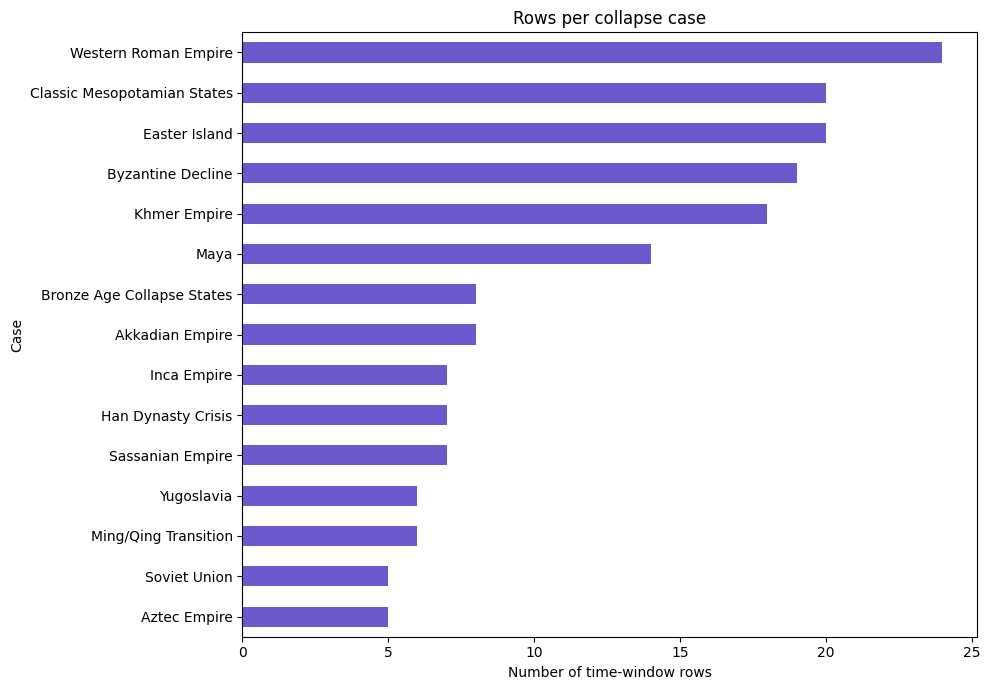

In [20]:
coverage_summary = pd.DataFrame(
    {
        "rows": [len(df)],
        "cases": [df["case_name"].nunique()],
        "regions": [df["region"].nunique()],
        "factor_columns": [len(factor_cols)],
    },
    index=["dataset"],
)

case_window_counts = df.groupby("case_name").size().sort_values(ascending=False).rename("row_count")
metadata_cols = ["phase_label", "collapse_outcome", "collapse_within_next_window", "data_confidence", "source_count"]
metadata_missing = df[metadata_cols].isna().sum().to_frame("missing_count")

display(coverage_summary)
display(case_window_counts.to_frame())
display(metadata_missing)

fig, ax = plt.subplots(figsize=(10, 7))
case_window_counts.sort_values().plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Rows per collapse case")
ax.set_xlabel("Number of time-window rows")
ax.set_ylabel("Case")
plt.tight_layout()
plt.show()

## Factor Frequency

The summaries below treat `9` as unknown. The main descriptive measure is the share of known observations where a factor is positive (`1`, `2`, or `3`).

,known_rows,unknown_rows,positive_rows,high_rows,positive_pct_of_known,high_pct_of_known,unknown_pct_of_rows
elite_conflict,147,27,147,106,100.0,72.1,15.5
social_inequality,109,65,109,84,100.0,77.1,37.4
corruption_governance_failure,58,116,58,55,100.0,94.8,66.7
administrative_overload,147,27,147,114,100.0,77.6,15.5
recovery_capacity,174,0,174,117,100.0,67.2,0.0
alliance_network_strength,154,20,154,64,100.0,41.6,11.5
logistics_food_storage_resilience,174,0,174,102,100.0,58.6,0.0
resource_dependency,173,1,173,133,100.0,76.9,0.6
institutional_rigidity,174,0,174,115,100.0,66.1,0.0
adaptive_capacity,174,0,174,111,100.0,63.8,0.0


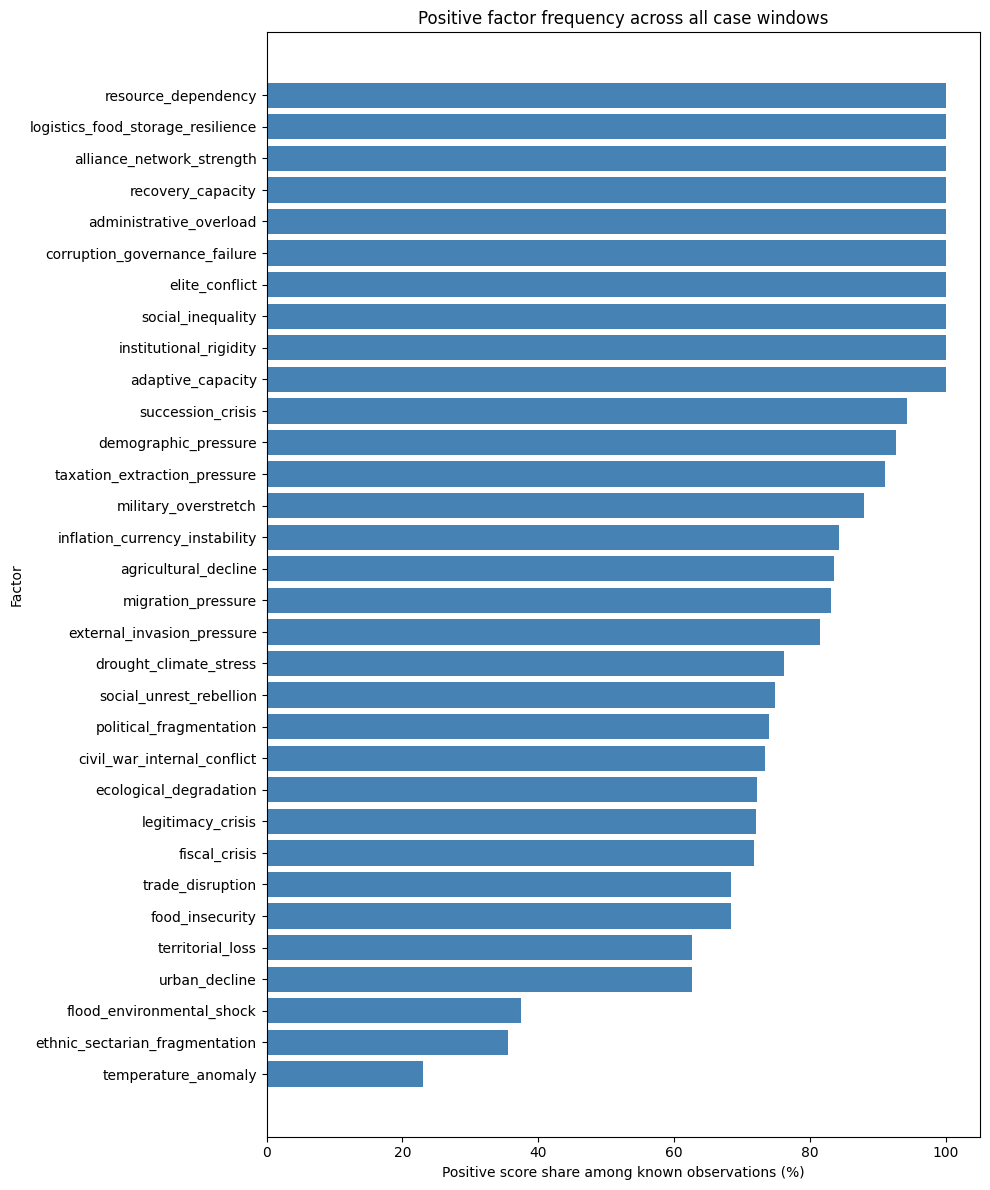

In [21]:
factor_summary = pd.DataFrame(
    {
        "known_rows": known_mask.sum(),
        "unknown_rows": len(df) - known_mask.sum(),
        "positive_rows": positive_mask.sum(),
        "high_rows": high_mask.sum(),
    }
)

factor_summary["positive_pct_of_known"] = (
    factor_summary["positive_rows"]
    .div(factor_summary["known_rows"].where(factor_summary["known_rows"].ne(0)))
    .mul(100)
    .round(1)
)
factor_summary["high_pct_of_known"] = (
    factor_summary["high_rows"]
    .div(factor_summary["known_rows"].where(factor_summary["known_rows"].ne(0)))
    .mul(100)
    .round(1)
)
factor_summary["unknown_pct_of_rows"] = (factor_summary["unknown_rows"] / len(df) * 100).round(1)
factor_summary = factor_summary.sort_values("positive_pct_of_known", ascending=False)

display(factor_summary)

plot_summary = factor_summary.sort_values("positive_pct_of_known", ascending=True)
fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(plot_summary.index, plot_summary["positive_pct_of_known"], color="steelblue")
ax.set_title("Positive factor frequency across all case windows")
ax.set_xlabel("Positive score share among known observations (%)")
ax.set_ylabel("Factor")
plt.tight_layout()
plt.show()

In [22]:
category_rows = []
for category, columns in category_map.items():
    category_known = int(known_mask[columns].sum().sum())
    category_positive = int(positive_mask[columns].sum().sum())
    category_high = int(high_mask[columns].sum().sum())
    category_rows.append(
        {
            "category": category,
            "known_scores": category_known,
            "positive_scores": category_positive,
            "high_scores": category_high,
            "positive_pct_of_known": round(category_positive / category_known * 100, 1) if category_known else None,
            "high_pct_of_known": round(category_high / category_known * 100, 1) if category_known else None,
        }
    )

category_summary = pd.DataFrame(category_rows).sort_values("positive_pct_of_known", ascending=False)
category_summary

,category,known_scores,positive_scores,high_scores,positive_pct_of_known,high_pct_of_known
5,Institutional / Resilience,850,850,509,100.0,59.9
0,Political,776,688,471,88.7,60.7
2,Economic,743,614,387,82.6,52.1
1,Social,602,460,259,76.4,43.0
4,Military / Geopolitical,647,493,320,76.2,49.5
3,Environmental,281,186,102,66.2,36.3


## Factor Co-Occurrence

This section identifies factor pairs that frequently appear together and then visualizes co-occurrence among the most common positive factors.

The heatmap uses Jaccard similarity over positive factor presence, excluding rows where either factor is unknown.

,left_factor,right_factor,shared_known_rows,co_positive_rows,jaccard
486,institutional_rigidity,adaptive_capacity,174,174,1.0
487,institutional_rigidity,logistics_food_storage_resilience,174,174,1.0
489,institutional_rigidity,recovery_capacity,174,174,1.0
490,adaptive_capacity,logistics_food_storage_resilience,174,174,1.0
492,adaptive_capacity,recovery_capacity,174,174,1.0
494,logistics_food_storage_resilience,recovery_capacity,174,174,1.0
386,resource_dependency,institutional_rigidity,173,173,1.0
387,resource_dependency,adaptive_capacity,173,173,1.0
388,resource_dependency,logistics_food_storage_resilience,173,173,1.0
390,resource_dependency,recovery_capacity,173,173,1.0


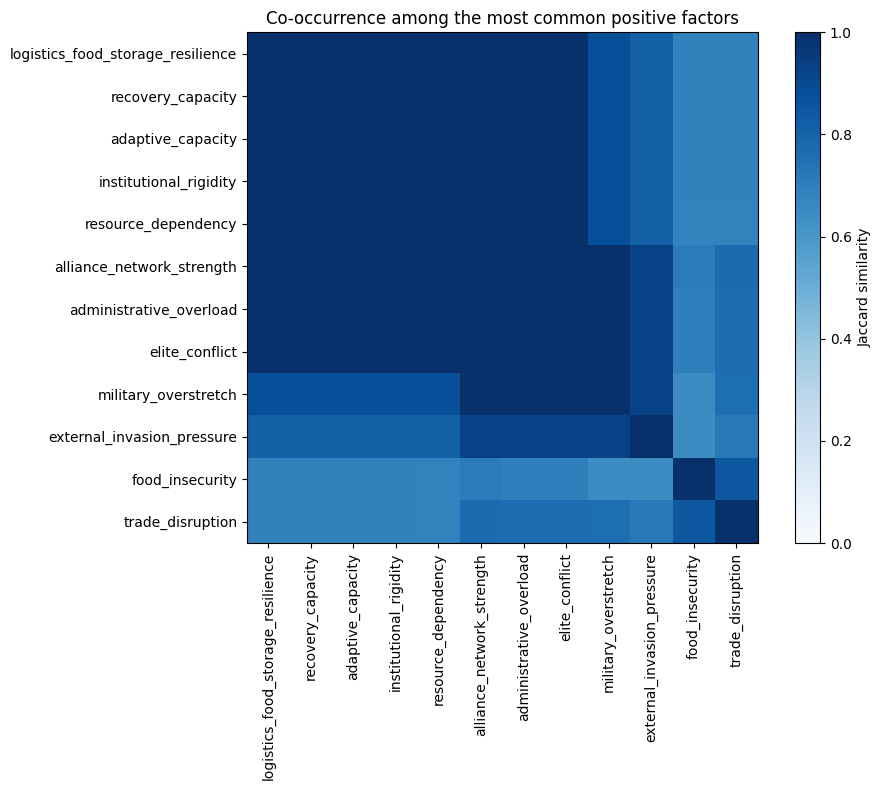

In [23]:
pair_rows = []
for index, left in enumerate(factor_cols):
    for right in factor_cols[index + 1 :]:
        shared_known = known_mask[left] & known_mask[right]
        shared_known_count = int(shared_known.sum())
        if shared_known_count == 0:
            continue

        left_positive = positive_mask[left] & shared_known
        right_positive = positive_mask[right] & shared_known
        intersection = int((left_positive & right_positive).sum())
        union = int((left_positive | right_positive).sum())
        pair_rows.append(
            {
                "left_factor": left,
                "right_factor": right,
                "shared_known_rows": shared_known_count,
                "co_positive_rows": intersection,
                "jaccard": round(intersection / union, 3) if union else 0.0,
            }
        )

pair_summary = pd.DataFrame(
    pair_rows,
    columns=["left_factor", "right_factor", "shared_known_rows", "co_positive_rows", "jaccard"],
)
if not pair_summary.empty:
    pair_summary = pair_summary.sort_values(["jaccard", "co_positive_rows"], ascending=False)
display(pair_summary.head(20))

top_factors = factor_summary.sort_values("positive_rows", ascending=False).head(12).index.tolist()
jaccard_matrix = pd.DataFrame(0.0, index=top_factors, columns=top_factors)

for left in top_factors:
    for right in top_factors:
        shared_known = known_mask[left] & known_mask[right]
        left_positive = positive_mask[left] & shared_known
        right_positive = positive_mask[right] & shared_known
        intersection = int((left_positive & right_positive).sum())
        union = int((left_positive | right_positive).sum())
        jaccard_matrix.loc[left, right] = intersection / union if union else 0.0

if int(known_mask.sum().sum()) == 0:
    print("No pairwise co-occurrence data yet: factor scores are still unknown or blank across the dataset.")
else:
    fig, ax = plt.subplots(figsize=(10, 8))
    image = ax.imshow(jaccard_matrix.values, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(top_factors)))
    ax.set_xticklabels(top_factors, rotation=90)
    ax.set_yticks(range(len(top_factors)))
    ax.set_yticklabels(top_factors)
    ax.set_title("Co-occurrence among the most common positive factors")
    fig.colorbar(image, ax=ax, label="Jaccard similarity")
    plt.tight_layout()
    plt.show()

## Cross-Case Comparison by Category

To keep the comparison readable, the table below collapses the factor list into category-level positive rates by case. This is descriptive only and should be interpreted cautiously because row counts differ across cases and many rows still contain unknown values.

,Political,Social,Economic,Environmental,Military / Geopolitical,Institutional / Resilience
case_name,,,,,,
Akkadian Empire,0.907,0.826,0.889,0.846,0.875,1.0
Aztec Empire,0.846,0.750,0.826,0.600,0.800,1.0
Bronze Age Collapse States,0.826,0.750,0.923,0.818,0.909,1.0
Byzantine Decline,0.982,0.971,0.978,0.947,0.974,1.0
Classic Mesopotamian States,0.946,0.885,0.930,0.857,0.919,1.0
Easter Island,NaN,0.460,0.500,0.783,0.000,1.0
Han Dynasty Crisis,1.000,1.000,1.000,1.000,1.000,1.0
Inca Empire,0.778,0.765,0.724,0.429,0.714,1.0
Khmer Empire,0.856,0.725,0.827,0.781,0.806,1.0


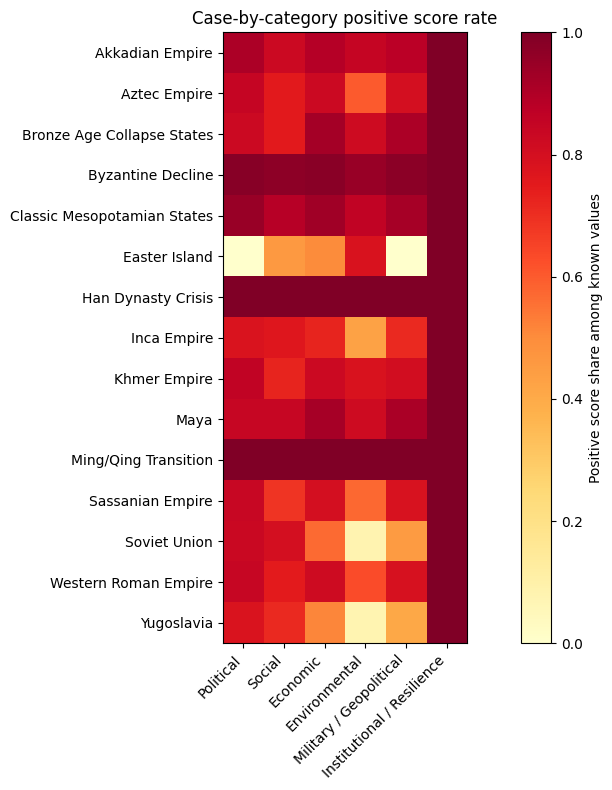

In [24]:
case_category_rates = {}
for category, columns in category_map.items():
    category_known_by_case = known_mask[columns].sum(axis=1).groupby(df["case_name"]).sum()
    category_positive_by_case = positive_mask[columns].sum(axis=1).groupby(df["case_name"]).sum()
    case_category_rates[category] = category_positive_by_case.div(category_known_by_case.where(category_known_by_case.ne(0)))

case_category_summary = pd.DataFrame(case_category_rates).sort_index()
display(case_category_summary.round(3))

heatmap_values = case_category_summary.fillna(0)
fig, ax = plt.subplots(figsize=(11, 8))
image = ax.imshow(heatmap_values.values, cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(len(heatmap_values.columns)))
ax.set_xticklabels(heatmap_values.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_values.index)))
ax.set_yticklabels(heatmap_values.index)
ax.set_title("Case-by-category positive score rate")
fig.colorbar(image, ax=ax, label="Positive score share among known values")
plt.tight_layout()
plt.show()

## Next Steps

Good follow-on analyses once the coding is denser:
- case-by-factor heatmaps with `9` explicitly masked
- pathway clustering using only rows with adequate source coverage
- factor-pair networks filtered by minimum shared-known thresholds
- comparisons between historical pathways and present-day fragility profiles